In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Input
from tensorflow.keras.optimizers import SGD

from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Model
%matplotlib inline

plt.rcParams["animation.html"] = "jshtml"

from tensorflow.keras import backend as K

In [2]:
nb_classes = 10
dropout = 0.5

# Build very simple neural network with 2 hidden layers
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation="relu"),
    Dropout(dropout),
    Dense(64, activation="relu"),
    Dropout(dropout),
    Dense(nb_classes, activation="softmax")
])


model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5 / 6)

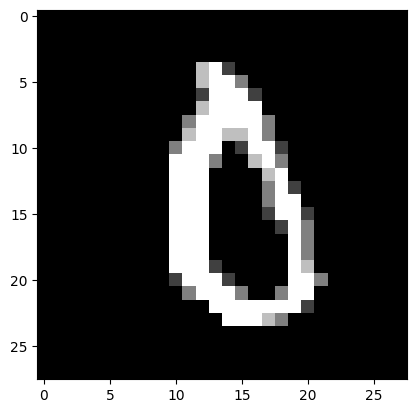

In [4]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")

In [5]:
network_history = model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(X_val, Y_val),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7968 - loss: 0.6546 - val_accuracy: 0.9327 - val_loss: 0.2301
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9148 - loss: 0.3040 - val_accuracy: 0.9490 - val_loss: 0.1730
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9325 - loss: 0.2395 - val_accuracy: 0.9551 - val_loss: 0.1530
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9427 - loss: 0.2026 - val_accuracy: 0.9604 - val_loss: 0.1321
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9506 - loss: 0.1787 - val_accuracy: 0.9661 - val_loss: 0.1235
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9549 - loss: 0.1634 - val_accuracy: 0.9676 - val_loss: 0.1151
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9569 - loss: 0.1526 - val_accuracy: 0.9687 - val_loss: 0.1123
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9597 - loss: 0.1420 - val_accuracy: 0.

In [6]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

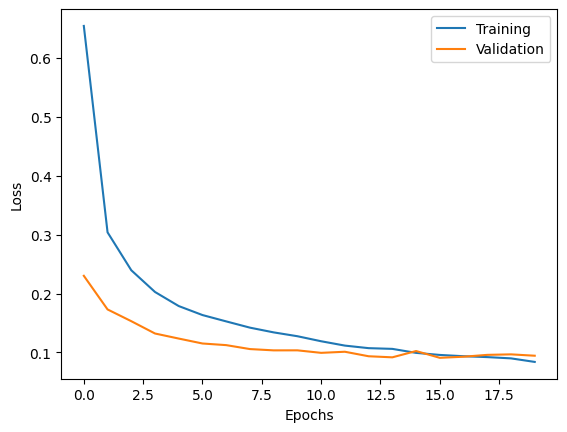

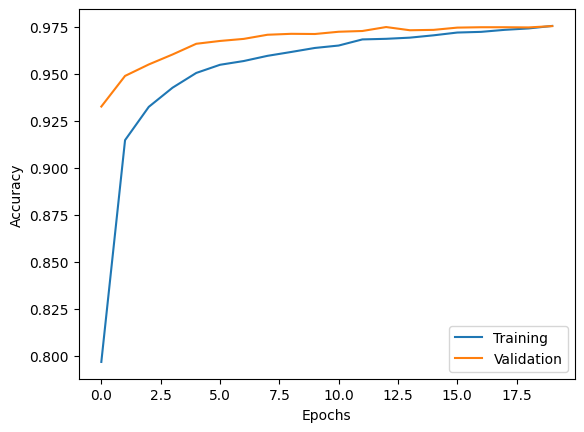

In [7]:
plot_history(network_history)

In [8]:
# Co ciekawe, na zbiorze walidacyjnym, mamy mniejszy błąd funkcji kosztu oraz większą dokładność. Prawdopodobnie, wynika to z zastosowania Dropoutu podczas treningu sieci, który jest już nieobecny przy walidacji, predykcji.
# Dropout to technika regualaryzacji, 50% neuronów nie działa, sieć działa w ograniczonym zakresie.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

In [ ]:
def build_intermediate_model(base_model, input_shape, layer_type=(Dense,)):
    inp = Input(shape=input_shape)
    x = inp
    outputs = []

    for layer in base_model.layers:
        x = layer(x)

        if isinstance(layer, layer_type):
            outputs.append(x)

    return Model(inputs=inp, outputs=outputs)


In [ ]:
layer_outputs_model = build_intermediate_model(
    model=model,
    input_shape=(784,),
    layer_type=(Dense,)
)

layer_outputs = layer_outputs_model(X_train)

In [19]:
layer1_output, layer2_output, layer3_output = layer_outputs_model(X_train)

In [20]:
train_ids = [np.arange(len(Y_train))[Y_train[:,i] == 1] for i in range(10)]


In [22]:
digit = 5
n_frames = 60

idx = np.where(y_test == digit)[0][:n_frames]
frames = X_test[idx]

h1, h2, out = layer_outputs_model(frames, training=False)
h1, h2, out = h1.numpy(), h2.numpy(), out.numpy()


In [24]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

im_input = axes[0].imshow(frames[0].reshape(28, 28), cmap='gray')
axes[0].set_title('Input digit'); axes[0].axis('off')

im_h1 = axes[1].imshow(h1[0].reshape(16, 16), cmap='gray',
                       vmin=0, vmax=h1.max())
axes[1].set_title('Hidden layer 1 (256)'); axes[1].axis('off')

im_h2 = axes[2].imshow(h2[0].reshape(8, 8), cmap='gray',
                       vmin=0, vmax=h2.max())
axes[2].set_title('Hidden layer 2 (64)'); axes[2].axis('off')

bars = axes[3].bar(range(10), out[0])
axes[3].set_ylim(0, 1); axes[3].set_xticks(range(10))
axes[3].set_title('Softmax output')

def update(i):
    im_input.set_data(frames[i].reshape(28, 28))
    im_h1.set_data(h1[i].reshape(16, 16))
    im_h2.set_data(h2[i].reshape(8, 8))
    for j, b in enumerate(bars):
        b.set_height(out[i][j])
    return [im_input, im_h1, im_h2, *bars]

ani = animation.FuncAnimation(fig, update, frames=n_frames,
                              interval=200, blit=False)
plt.close(fig)
ani
